# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [29]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [30]:
closes = {}
opens = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']
        if 'Open' in df.columns:
            opens[fp.stem] = df['Open']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
panel_open = pd.DataFrame(opens).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 176 只 ETF，2919 个交易日
日期范围: 2014-03-05 ~ 2026-03-10


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [31]:
def rolling_linreg(log_close: pd.DataFrame, n: int):
    """对 log(close) 面板做滚动 n 日线性回归，返回 (slope, R²) 两个面板。

    数学模型: y = a + b*x，其中
      x = [0, 1, 2, ..., n-1]   （时间序号，固定）
      y = log(close) 的滚动窗口  （每天、每只 ETF 各一个窗口）

    用最小二乘解析公式（非迭代）一次性计算全部日期×全部ETF的 slope(b) 和 R²。

    slope > 0 表示该 ETF 在过去 n 天呈上涨趋势，slope 越大涨势越强。
    R² 接近 1 表示趋势非常线性（稳定上涨），R² 低表示波动大、趋势不稳。
    """
    # ── 解析公式所需的 x 侧常量（与数据无关，只取决于窗口长度 n）──
    # Σx = 0+1+...+(n-1) = n(n-1)/2
    sum_x = n * (n - 1) / 2
    # Σx² = 0²+1²+...+(n-1)² = n(n-1)(2n-1)/6
    sum_x2 = n * (n - 1) * (2 * n - 1) / 6
    # 分母 = n*Σx² - (Σx)²
    denom_x = n * sum_x2 - sum_x ** 2

    # x 权重向量 [0, 1, 2, ..., n-1]，用于计算 Σ(x*y)
    weights = np.arange(n, dtype=float)

    # ── 滚动计算 y 侧统计量（向量化，对全部 ETF 列同时计算）──
    # Σy: 窗口内 log(close) 的求和
    roll_sum_y = log_close.rolling(n).sum()
    # Σy²: 窗口内 log(close)² 的求和
    roll_sum_y2 = (log_close ** 2).rolling(n).sum()
    # Σ(x*y): 窗口内 x[i]*y[i] 的求和，等价于 dot([0,1,...,n-1], window)
    roll_sum_xy = log_close.rolling(n).apply(lambda w: np.dot(weights, w), raw=True)

    # ── 最小二乘斜率 b = (n*Σxy - Σx*Σy) / (n*Σx² - (Σx)²) ──
    slope = (n * roll_sum_xy - sum_x * roll_sum_y) / denom_x

    # ── R² = SS_reg / SS_tot ──
    # SS_tot = n*Σy² - (Σy)²  （总离差平方和 × n，等比例不影响 R²）
    ss_tot = n * roll_sum_y2 - roll_sum_y ** 2
    # SS_reg = (n*Σxy - Σx*Σy)² / (n*Σx² - (Σx)²)  （回归平方和 × n）
    ss_reg = (n * roll_sum_xy - sum_x * roll_sum_y) ** 2 / denom_x
    # R² = SS_reg / SS_tot，SS_tot=0 时设为 NaN，最终 clip 到 [0,1]
    r2 = ss_reg / ss_tot.replace(0, np.nan)
    r2 = r2.clip(0, 1)

    return slope, r2


# ══════════════════════════════════════════════════════════════════════
# 交易成本参数
# ══════════════════════════════════════════════════════════════════════
SLIPPAGE = 0.001       # 滑点 0.1%: 买入价 = open*(1+0.001)，卖出价 = open*(1-0.001)
COMMISSION = 0.00006   # 单边手续费 0.006%（买一次扣一次，卖一次扣一次）

# ══════════════════════════════════════════════════════════════════════
# 预计算中间量（后续所有参数组合的回测复用，不重复计算）
# ══════════════════════════════════════════════════════════════════════
# log_close: 对收盘价取自然对数，用于线性回归（log空间下的线性=价格空间下的指数增长）
log_close = np.log(panel.replace(0, np.nan))
# daily_ret: 每日收益率 = (close[t] - close[t-1]) / close[t-1]
daily_ret = panel.pct_change()
# linreg_cache: {n: (slope_df, r2_df)}，对每个 n 只计算一次
linreg_cache = {}

def precompute_linreg(n_list):
    """对所有 n 值预计算 slope / R²，缓存到 linreg_cache。"""
    for n in n_list:
        if n not in linreg_cache:
            linreg_cache[n] = rolling_linreg(log_close, n)
            print(f'  预计算 rolling_linreg(n={n}) 完成')


# ══════════════════════════════════════════════════════════════════════
# 核心回测函数
# ══════════════════════════════════════════════════════════════════════
def backtest_momentum(
    slope: pd.DataFrame,
    r2: pd.DataFrame,
    daily_ret: pd.DataFrame,
    n: int,
    r2_threshold: float,
    rebal_period: int,
    top_k: int = 1,
    slippage: float = SLIPPAGE,
    commission: float = COMMISSION,
) -> pd.Series:
    """基于预计算的 slope/R² 运行回测，返回每日净值序列 (NAV)。

    ┌─────────────────────────────────────────────────────────────┐
    │ 实盘时序模型                                                  │
    │                                                             │
    │  T日(信号日)收盘后:                                           │
    │    用 close(T) 计算 slope、R²，选出下期应持有的 top_k 只标的     │
    │                                                             │
    │  T+1日(执行日)开盘:                                           │
    │    卖出旧持仓: 卖出价 = open(T+1) × (1 - slippage)            │
    │    买入新持仓: 买入价 = open(T+1) × (1 + slippage)            │
    │    每笔买/卖各扣 commission 手续费                              │
    │                                                             │
    │  T+1日收盘:                                                  │
    │    当天收益 = close(T+1) / 买入价 - 1                          │
    │                                                             │
    │  T+2 ~ 下次执行日前:                                          │
    │    每天收益 = close(t) / close(t-1) - 1  (close-to-close)     │
    └─────────────────────────────────────────────────────────────┘

    参数说明:
      slope, r2    : 预计算好的面板 (日期×ETF)
      daily_ret    : 每日收益率面板 (close-to-close)
      n            : 动量回看天数（线性回归窗口）
      r2_threshold : R² 过滤阈值，只选 R² >= 阈值的候选标的
      rebal_period : 调仓周期（交易日），每隔多少天重新选股
      top_k        : 每次持有多少只 ETF（等权分配）
      slippage     : 滑点（买卖各 0.1%）
      commission   : 单边手续费（买卖各 0.006%）

    返回:
      pd.Series，index=日期，values=每日净值（从 1.0 开始）
    """

    # ── 第一步：确定回测起始日 ──
    # 跳过前 n+5 天（前 n 天用于线性回归窗口，再留 5 天缓冲确保数据稳定）
    start_idx = n + 5
    dates = daily_ret.index[start_idx:]

    # ── 第二步：在每个"信号日"计算选股结果 ──
    # rebal_indices: [0, rebal_period, 2*rebal_period, ...]
    # 即 dates 数组中第 0、rebal_period、2*rebal_period... 天为信号日
    rebal_indices = list(range(0, len(dates), rebal_period))

    # signal_map: {dates数组中的位置索引 -> 选出的ETF代码列表}
    signal_map = {}
    for idx_pos in rebal_indices:
        date = dates[idx_pos]

        # 取当天所有 ETF 的 slope 和 R²，去掉 NaN
        s = slope.loc[date].dropna()
        r = r2.loc[date].dropna()

        # 只保留 slope 和 R² 都有值的 ETF
        common = s.index.intersection(r.index)
        s, r = s[common], r[common]

        # 筛选: R² >= 阈值，按 slope 降序排列（动量最强的排前面）
        candidates = s[r >= r2_threshold].sort_values(ascending=False)

        # 取前 top_k 只；如果没有任何候选则空仓 []
        selected = candidates.head(top_k).index.tolist() if len(candidates) >= 1 else []
        signal_map[idx_pos] = selected

    # ── 第三步：信号日→执行日映射 ──
    # 信号在 T 日收盘后产生，T+1 日执行
    # exec_map: {执行日在dates中的位置 -> 要切换到的持仓列表}
    exec_map = {}
    for sig_idx, selected in signal_map.items():
        exec_idx = sig_idx + 1          # T+1
        if exec_idx < len(dates):       # 最后一天的信号无法执行
            exec_map[exec_idx] = selected

    # ── 第四步：逐日模拟净值 ──
    #
    # 仓位模型（关键）:
    #   总资金分为 top_k 等份，每份权重 w = 1/top_k
    #   若实际选出 k 只标的（k <= top_k），则:
    #     - k 份投入标的，每只占 1/top_k
    #     - (top_k - k) 份为现金，收益率 = 0
    #   组合收益 = Σ(每只标的收益 × 1/top_k) + 现金部分×0
    #            = Σ(每只标的收益) / top_k    （不是除以 k !）
    #
    #   手续费同理：只对实际交易的仓位收费
    #     卖 k_sell 只: 手续费 = k_sell/top_k × commission
    #     买 k_buy 只:  手续费 = k_buy/top_k × commission

    cum = 1.0                           # 累计净值，从 1.0 开始
    nav_values = np.ones(len(dates))    # 存储每天的净值
    current_holdings = []               # 当前持有的 ETF 代码列表

    for d in range(len(dates)):
        date = dates[d]

        # ─── 场景A：今天是执行日（需要换仓）───
        if d in exec_map:
            new_holdings = exec_map[d]

            # 只有持仓真正发生变化时才执行交易（避免无意义的买卖摩擦）
            if sorted(new_holdings) != sorted(current_holdings):

                # ①【卖出旧持仓】
                # 每只旧持仓权重 = 1/top_k
                # 卖出价 = 今天的 open × (1 - slippage)
                # 该只的收益 = 卖出价 / 昨日close - 1
                # 对组合的贡献 = 收益 × (1/top_k)
                if current_holdings and d > 0:
                    prev_date = dates[d - 1]
                    k_sell = len(current_holdings)
                    sell_rets = []
                    for sym in current_holdings:
                        prev_cl = panel.loc[prev_date, sym]
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        sell_price = op * (1 - slippage)
                        sell_rets.append(sell_price / prev_cl - 1)
                    # 组合卖出收益 = Σ(各标的收益) / top_k
                    # 现金部分 (top_k - k_sell) 份收益为 0，自动体现在除以 top_k 中
                    portfolio_sell_ret = np.nansum(sell_rets) / top_k
                    cum *= (1 + portfolio_sell_ret)
                    # 手续费只对实际卖出的仓位收: k_sell/top_k × commission
                    cum *= (1 - k_sell / top_k * commission)

                # ②【买入新持仓】
                # 每只新持仓权重 = 1/top_k
                # 买入价 = 今天的 open × (1 + slippage)
                # 当天收益 = close / 买入价 - 1
                if new_holdings:
                    k_buy = len(new_holdings)
                    # 手续费只对实际买入的仓位收: k_buy/top_k × commission
                    cum *= (1 - k_buy / top_k * commission)
                    buy_rets = []
                    for sym in new_holdings:
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        buy_price = op * (1 + slippage)
                        cl = panel.loc[date, sym]
                        buy_rets.append(cl / buy_price - 1)
                    # 组合买入当天收益 = Σ(各标的收益) / top_k
                    portfolio_buy_ret = np.nansum(buy_rets) / top_k
                    cum *= (1 + portfolio_buy_ret)

                current_holdings = new_holdings

            else:
                # 持仓未变（新选出的标的和当前持仓完全一样），不交易
                # 按正常 close-to-close 计算当天收益
                if current_holdings:
                    # 组合收益 = Σ(各标的日收益) / top_k，而非 mean
                    rets = daily_ret.loc[date, current_holdings]
                    portfolio_ret = np.nansum(rets.values) / top_k
                    cum *= (1 + portfolio_ret)

        # ─── 场景B：今天是普通持仓日（不换仓）───
        else:
            if current_holdings:
                # 组合收益 = Σ(各标的日收益) / top_k
                # 若持仓 k < top_k，剩余 (top_k-k)/top_k 为现金，收益=0
                rets = daily_ret.loc[date, current_holdings]
                portfolio_ret = np.nansum(rets.values) / top_k
                cum *= (1 + portfolio_ret)

        # 记录当天净值
        nav_values[d] = cum

    return pd.Series(nav_values, index=dates, name='NAV')

## 3. 定义参数网格

In [ ]:
N_LIST = [5, 10, 15, 20, 25, 30, 40, 50]      # 动量回看天数
R2_LIST = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]          # R² 阈值
REBAL_LIST = [5, 10, 15, 20, 30, 60]                  # 调仓周期（交易日）
TOP_K_LIST = [1, 2, 3, 5, 10]                        # 每次持有 ETF 数量（网格）

param_grid = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
print(f'参数组合数: {len(param_grid)}')

参数组合数: 2240


## 4. 批量回测

In [33]:
import time as _time
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
import os as _os

# ══════════════════════════════════════════════════════════════════════
# 预计算所有 n 值的线性回归（最耗时步骤，每个 n 只算一次，多个参数组合复用）
# linreg_cache 结构: {n: (slope_df, r2_df)}
# slope_df / r2_df 形状: (交易日数 × ETF数)
# ══════════════════════════════════════════════════════════════════════
print('预计算 rolling linreg ...')
precompute_linreg(N_LIST)

# ══════════════════════════════════════════════════════════════════════
# 多进程并行回测
#
# 原理: 每个参数组合 (n, R2, rebal, top_k) 的回测完全独立，
# 使用 fork 模式创建子进程，子进程通过 copy-on-write 共享
# panel, panel_open, daily_ret, linreg_cache 等大型 DataFrame，
# 无需序列化传输，零额外内存开销。
# ══════════════════════════════════════════════════════════════════════
_NUM_WORKERS = max(1, _os.cpu_count() - 1)  # CPU核数-1，留1核给系统

def _bt_one(params):
    """单个参数组合的回测 + 绩效指标计算。

    在 worker 进程中执行，通过 fork 继承父进程的
    linreg_cache, daily_ret, panel, panel_open 等全局变量。
    """
    n, r2_thresh, rebal, top_k = params

    # 从缓存中取出该 n 值对应的 slope 和 R² 面板
    slope, r2 = linreg_cache[n]

    # 运行回测，得到逐日净值序列
    nav = backtest_momentum(slope, r2, daily_ret, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k)

    # 构造唯一标签，用于 nav_cache 索引
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'

    # ── 计算逐年收益率 ──
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:       # 不足10个交易日的年份跳过（如数据起始/结束年）
            continue
        # 该年收益 = 年末净值 / 年初净值 - 1
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    # "完整年"= 排除首尾不完整的年份（数据起始年和当前年可能不足12个月）
    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    # ── 计算汇总指标 ──
    # 总收益 = 最终净值 / 初始净值 - 1
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    # 回测跨越的年数（用于年化）
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    # 年化收益 = (1 + total_ret)^(1/n_years) - 1
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    # 最大回撤 = max(1 - NAV[t] / NAV历史最高)，取负值
    max_dd = ((nav / nav.cummax()) - 1).min()

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)     # 每年收益率也存入，如 {2014: 0.12, 2015: -0.05, ...}
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['max_drawdown'] = max_dd
    return label, nav, row

print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数 ...')

t0 = _time.time()
# fork: 子进程继承父进程内存空间（copy-on-write），避免序列化大 DataFrame
_ctx = _mp.get_context('fork')
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    # chunksize=20: 每次给 worker 分配20个任务，减少进程间通信次数
    _all_results = list(executor.map(_bt_one, param_grid, chunksize=20))

# 收集结果
results = []        # 每个参数组合的绩效指标 (dict)
nav_cache = {}      # 每个参数组合的逐日净值序列 (pd.Series)，后续画图用
for label, nav, row in _all_results:
    nav_cache[label] = nav
    results.append(row)

elapsed = _time.time() - t0
print(f'\n回测完成，共 {len(results)} 组参数，耗时 {elapsed:.1f}s')

预计算 rolling linreg ...
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=10) 完成
  预计算 rolling_linreg(n=15) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=25) 完成
  预计算 rolling_linreg(n=30) 完成
  预计算 rolling_linreg(n=40) 完成
  预计算 rolling_linreg(n=50) 完成
使用 9 个进程并行回测 2240 组参数 ...

回测完成，共 2240 组参数，耗时 113.2s


## 5. 结果总览

In [35]:
result_df = pd.DataFrame(results)
result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

display_df = result_df.copy()
for c in fmt_cols:
    if c in display_df.columns:
        display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

display_df = display_df.sort_values('annualized', ascending=False, key=lambda s: result_df['annualized'])

print('所有参数组合回测结果（按年化收益排序）:')
display(display_df.head(30))

所有参数组合回测结果（按年化收益排序）:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
64,5,0.4,15,10,24.85%,14.10%,-8.43%,65.34%,-24.13%,9.94%,...,-17.59%,10.71%,969.69%,-15.04%,48.89%,-1.27%,100.02%,34.00%,3226.64%,-43.94%
63,5,0.4,15,5,24.48%,-23.38%,-5.97%,128.41%,-28.02%,-17.91%,...,-21.21%,-2.71%,1844.01%,-13.74%,35.86%,-3.17%,176.65%,33.61%,3114.45%,-55.75%
24,5,0.3,15,10,23.87%,7.72%,-6.31%,63.15%,-26.90%,9.38%,...,-11.10%,-8.46%,964.45%,-16.24%,51.43%,-1.27%,97.30%,31.36%,2521.72%,-46.28%
1833,40,0.6,30,5,19.96%,-7.39%,-0.16%,12.20%,-10.47%,16.50%,...,71.86%,-12.08%,-3.89%,-15.38%,932.16%,-2.09%,92.03%,30.31%,2189.70%,-58.68%
1713,40,0.3,30,5,22.85%,12.99%,-14.17%,18.84%,-15.15%,15.52%,...,71.54%,-25.72%,-6.19%,-5.02%,994.13%,4.25%,97.57%,30.27%,2182.10%,-67.12%
1753,40,0.4,30,5,23.09%,12.80%,-12.55%,18.00%,-15.23%,15.38%,...,73.78%,-23.95%,-6.19%,-13.20%,965.73%,-1.25%,94.84%,29.58%,2043.79%,-65.67%
627,15,0.4,20,3,66.24%,3.38%,21.66%,53.48%,-12.29%,12.40%,...,357.49%,-7.63%,-3.30%,0.40%,11.37%,26.43%,41.03%,28.92%,1974.28%,-49.17%
1746,40,0.4,20,2,44.53%,27.28%,-0.82%,27.83%,-10.39%,0.93%,...,263.82%,-16.11%,20.14%,11.42%,76.09%,6.84%,38.32%,28.86%,1906.83%,-55.28%
667,15,0.5,20,3,48.42%,-8.10%,19.55%,58.65%,-19.40%,37.29%,...,377.08%,-3.33%,3.68%,-1.08%,5.41%,26.43%,43.88%,28.72%,1936.37%,-55.77%
1793,40,0.5,30,5,21.34%,4.04%,-16.24%,18.65%,-10.54%,11.77%,...,71.06%,-22.62%,-1.13%,-14.23%,916.16%,-3.33%,89.64%,28.26%,1798.87%,-63.43%


## 6. 最优参数组合 Top 10

In [36]:
top10 = result_df.nlargest(10, 'annualized')[['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']].copy()
for c in fmt_cols:
    if c in top10.columns:
        top10[c] = top10[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
top10.index = range(1, len(top10) + 1)
top10.index.name = '排名'
print('年化收益 Top 10 参数组合:')
display(top10)

年化收益 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.4,15,10,24.85%,14.10%,-8.43%,65.34%,-24.13%,9.94%,...,-17.59%,10.71%,969.69%,-15.04%,48.89%,-1.27%,100.02%,34.00%,3226.64%,-43.94%
2,5,0.4,15,5,24.48%,-23.38%,-5.97%,128.41%,-28.02%,-17.91%,...,-21.21%,-2.71%,1844.01%,-13.74%,35.86%,-3.17%,176.65%,33.61%,3114.45%,-55.75%
3,5,0.3,15,10,23.87%,7.72%,-6.31%,63.15%,-26.90%,9.38%,...,-11.10%,-8.46%,964.45%,-16.24%,51.43%,-1.27%,97.30%,31.36%,2521.72%,-46.28%
4,40,0.6,30,5,19.96%,-7.39%,-0.16%,12.20%,-10.47%,16.50%,...,71.86%,-12.08%,-3.89%,-15.38%,932.16%,-2.09%,92.03%,30.31%,2189.70%,-58.68%
5,40,0.3,30,5,22.85%,12.99%,-14.17%,18.84%,-15.15%,15.52%,...,71.54%,-25.72%,-6.19%,-5.02%,994.13%,4.25%,97.57%,30.27%,2182.10%,-67.12%
6,40,0.4,30,5,23.09%,12.80%,-12.55%,18.00%,-15.23%,15.38%,...,73.78%,-23.95%,-6.19%,-13.20%,965.73%,-1.25%,94.84%,29.58%,2043.79%,-65.67%
7,15,0.4,20,3,66.24%,3.38%,21.66%,53.48%,-12.29%,12.40%,...,357.49%,-7.63%,-3.30%,0.40%,11.37%,26.43%,41.03%,28.92%,1974.28%,-49.17%
8,40,0.4,20,2,44.53%,27.28%,-0.82%,27.83%,-10.39%,0.93%,...,263.82%,-16.11%,20.14%,11.42%,76.09%,6.84%,38.32%,28.86%,1906.83%,-55.28%
9,15,0.5,20,3,48.42%,-8.10%,19.55%,58.65%,-19.40%,37.29%,...,377.08%,-3.33%,3.68%,-1.08%,5.41%,26.43%,43.88%,28.72%,1936.37%,-55.77%


## 7. 热力图分析

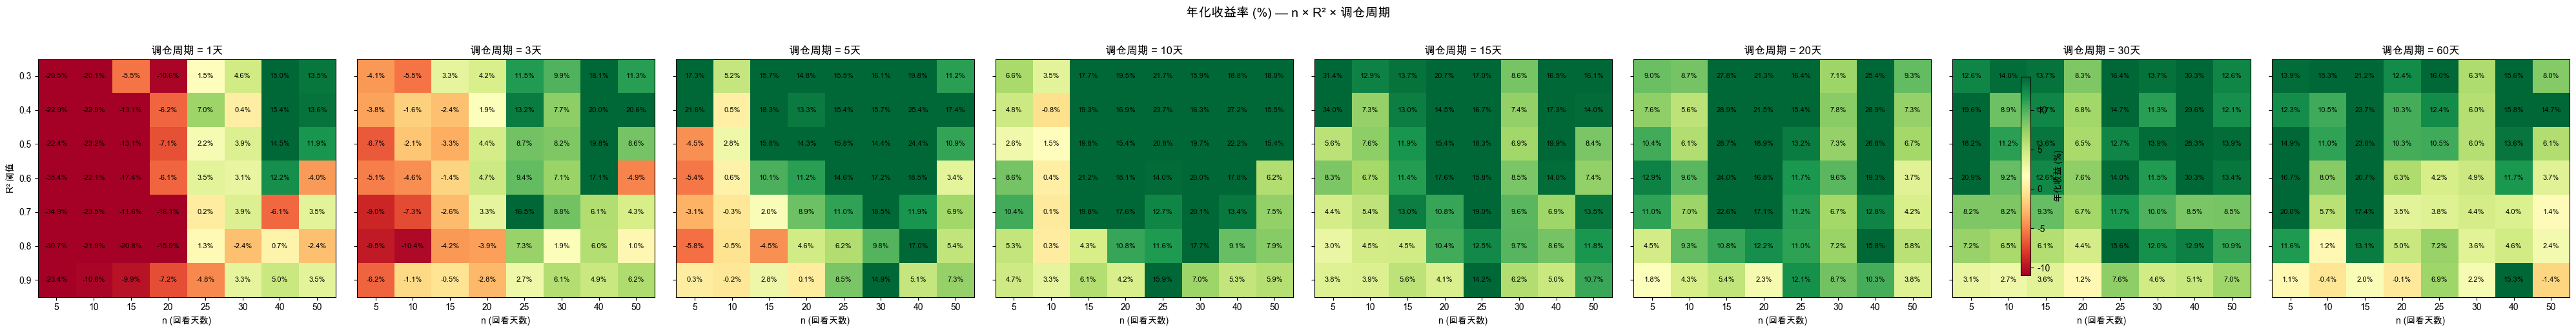

In [37]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Heiti TC']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, len(REBAL_LIST), figsize=(5 * len(REBAL_LIST), 5), sharey=True)
if len(REBAL_LIST) == 1:
    axes = [axes]

for ax, rebal in zip(axes, REBAL_LIST):
    subset = result_df[result_df['rebal_period'] == rebal]
    # 每个 (R2_threshold, n) 有多个 top_k，取年化最大后再 pivot
    agg = subset.groupby(['R2_threshold', 'n'], as_index=False)['annualized'].max()
    pivot = agg.pivot(index='R2_threshold', columns='n', values='annualized') * 100
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=result_df['annualized'].quantile(0.1) * 100,
                   vmax=result_df['annualized'].quantile(0.9) * 100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
    ax.set_xlabel('n (回看天数)')
    if rebal == REBAL_LIST[0]:
        ax.set_ylabel('R² 阈值')
    ax.set_title(f'调仓周期 = {rebal}天')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8)

fig.suptitle('年化收益率 (%) — n × R² × 调仓周期', fontsize=14, y=1.02)
fig.colorbar(im, ax=axes, label='年化收益 (%)', shrink=0.8)
plt.tight_layout()
plt.show()

## 8. Top 10 参数净值曲线 & 基准对比

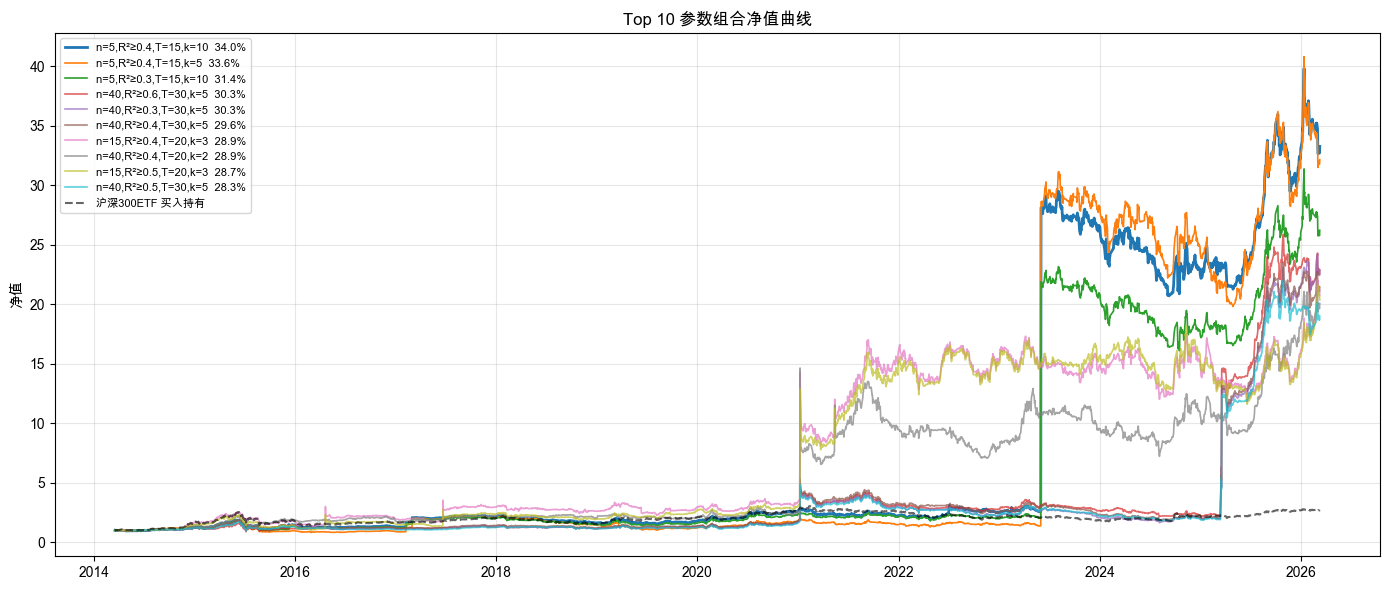

Top 10 参数详情:
  #1  n=5, R²≥0.4, T=15, k=10  年化=34.00%  累计=3226.64%  回撤=-43.94%
  #2  n=5, R²≥0.4, T=15, k=5  年化=33.61%  累计=3114.45%  回撤=-55.75%
  #3  n=5, R²≥0.3, T=15, k=10  年化=31.36%  累计=2521.72%  回撤=-46.28%
  #4  n=40, R²≥0.6, T=30, k=5  年化=30.31%  累计=2189.70%  回撤=-58.68%
  #5  n=40, R²≥0.3, T=30, k=5  年化=30.27%  累计=2182.10%  回撤=-67.12%
  #6  n=40, R²≥0.4, T=30, k=5  年化=29.58%  累计=2043.79%  回撤=-65.67%
  #7  n=15, R²≥0.4, T=20, k=3  年化=28.92%  累计=1974.28%  回撤=-49.17%
  #8  n=40, R²≥0.4, T=20, k=2  年化=28.86%  累计=1906.83%  回撤=-55.28%
  #9  n=15, R²≥0.5, T=20, k=3  年化=28.72%  累计=1936.37%  回撤=-55.77%
  #10  n=40, R²≥0.5, T=30, k=5  年化=28.26%  累计=1798.87%  回撤=-63.43%


In [38]:
top10_rows = result_df.nlargest(10, 'annualized')

# 基准：沪深300 ETF (SH510300) 买入持有
bench_sym = 'SH510300'
first_nav = nav_cache[
    f"n={int(top10_rows.iloc[0]['n'])}_R2={top10_rows.iloc[0]['R2_threshold']}"
    f"_rebal={int(top10_rows.iloc[0]['rebal_period'])}_topk={int(top10_rows.iloc[0]['top_k'])}"
]
if bench_sym in panel.columns:
    bench = panel[bench_sym].reindex(first_nav.index).ffill()
    bench_nav = bench / bench.iloc[0]
else:
    bench_nav = None

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, (_, row) in enumerate(top10_rows.iterrows()):
    label = f"n={int(row['n'])}_R2={row['R2_threshold']}_rebal={int(row['rebal_period'])}_topk={int(row['top_k'])}"
    nav = nav_cache[label]
    short_label = f"n={int(row['n'])},R²≥{row['R2_threshold']},T={int(row['rebal_period'])},k={int(row['top_k'])}  {row['annualized']:.1%}"
    lw = 2.0 if i == 0 else 1.2
    alpha = 1.0 if i < 3 else 0.7
    ax.plot(nav.index, nav.values, label=short_label, linewidth=lw, alpha=alpha, color=colors[i])

if bench_nav is not None:
    ax.plot(bench_nav.index, bench_nav.values, label='沪深300ETF 买入持有',
            linewidth=1.5, color='black', linestyle='--', alpha=0.6)

ax.set_ylabel('净值')
ax.set_title('Top 10 参数组合净值曲线')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 参数详情:')
for i, (_, row) in enumerate(top10_rows.iterrows()):
    print(f'  #{i+1}  n={int(row["n"])}, R²≥{row["R2_threshold"]}, T={int(row["rebal_period"])}, k={int(row["top_k"])}  '
          f'年化={row["annualized"]:.2%}  累计={row["total_ret"]:.2%}  回撤={row["max_drawdown"]:.2%}')

## 9. 按维度聚合分析

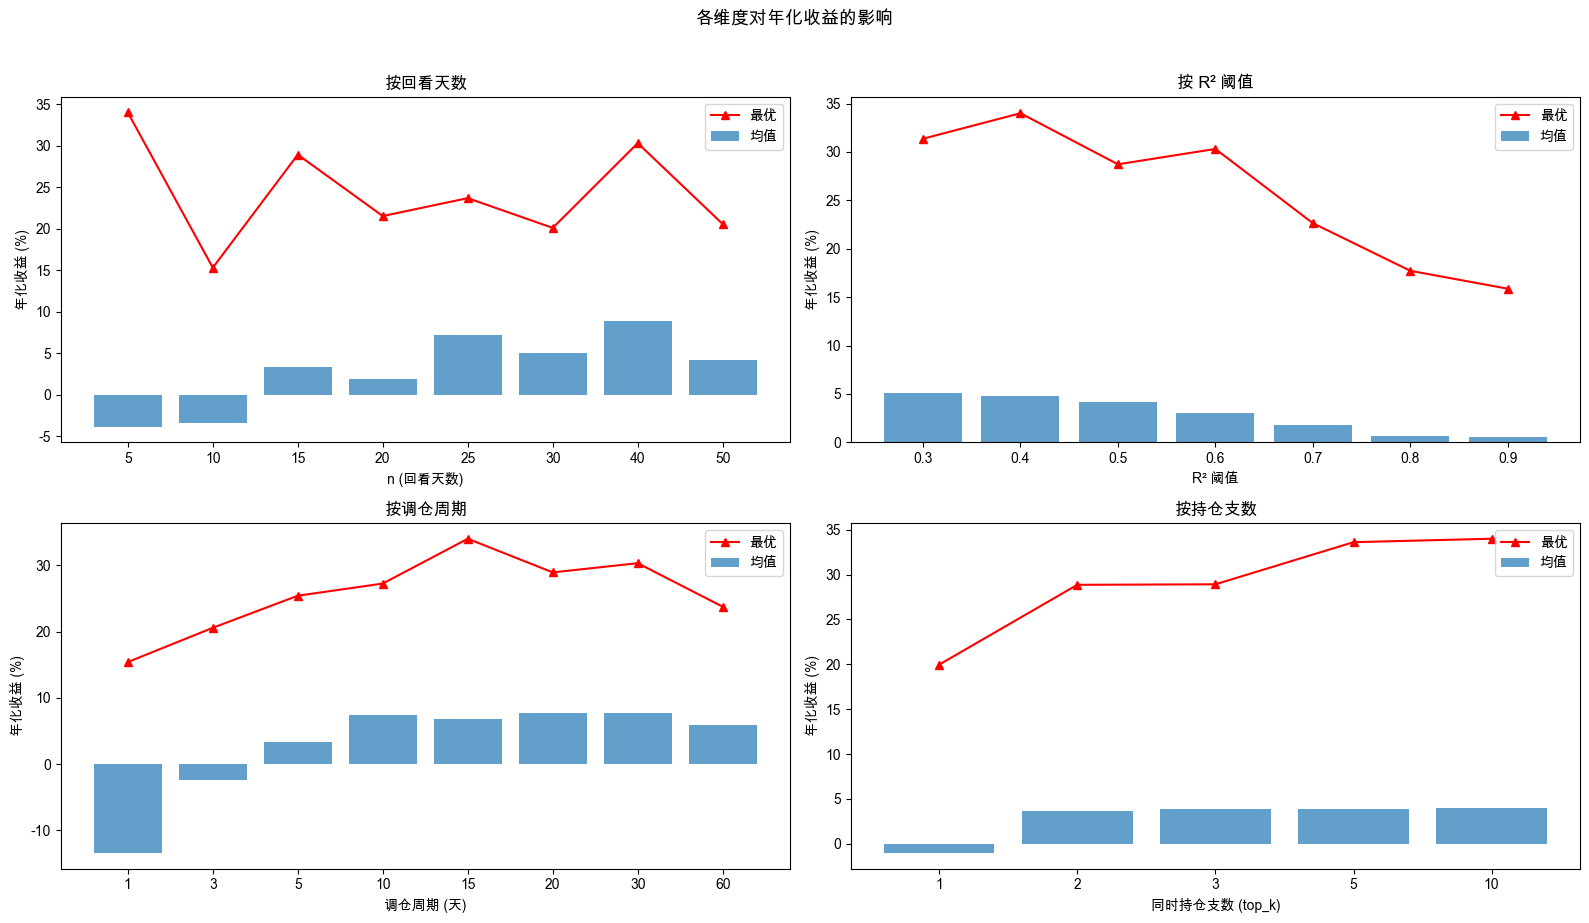

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# 按 n 聚合
by_n = result_df.groupby('n')['annualized'].agg(['mean', 'max'])
axes[0, 0].bar(by_n.index.astype(str), by_n['mean'] * 100, alpha=0.7, label='均值')
axes[0, 0].plot(by_n.index.astype(str), by_n['max'] * 100, 'r^-', label='最优')
axes[0, 0].set_xlabel('n (回看天数)')
axes[0, 0].set_ylabel('年化收益 (%)')
axes[0, 0].set_title('按回看天数')
axes[0, 0].legend()

# 按 R² 聚合
by_r2 = result_df.groupby('R2_threshold')['annualized'].agg(['mean', 'max'])
axes[0, 1].bar(by_r2.index.astype(str), by_r2['mean'] * 100, alpha=0.7, label='均值')
axes[0, 1].plot(by_r2.index.astype(str), by_r2['max'] * 100, 'r^-', label='最优')
axes[0, 1].set_xlabel('R² 阈值')
axes[0, 1].set_ylabel('年化收益 (%)')
axes[0, 1].set_title('按 R² 阈值')
axes[0, 1].legend()

# 按调仓周期聚合
by_rebal = result_df.groupby('rebal_period')['annualized'].agg(['mean', 'max'])
axes[1, 0].bar(by_rebal.index.astype(str), by_rebal['mean'] * 100, alpha=0.7, label='均值')
axes[1, 0].plot(by_rebal.index.astype(str), by_rebal['max'] * 100, 'r^-', label='最优')
axes[1, 0].set_xlabel('调仓周期 (天)')
axes[1, 0].set_ylabel('年化收益 (%)')
axes[1, 0].set_title('按调仓周期')
axes[1, 0].legend()

# 按同时持仓支数聚合
by_topk = result_df.groupby('top_k')['annualized'].agg(['mean', 'max'])
axes[1, 1].bar(by_topk.index.astype(str), by_topk['mean'] * 100, alpha=0.7, label='均值')
axes[1, 1].plot(by_topk.index.astype(str), by_topk['max'] * 100, 'r^-', label='最优')
axes[1, 1].set_xlabel('同时持仓支数 (top_k)')
axes[1, 1].set_ylabel('年化收益 (%)')
axes[1, 1].set_title('按持仓支数')
axes[1, 1].legend()

fig.suptitle('各维度对年化收益的影响', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. 每年收益率详细对比

In [41]:
# 选出 Top5 参数，展示逐年收益率对比
top5 = result_df.nlargest(5, 'annualized')

year_data = []
for _, row in top5.iterrows():
    label = f"n={int(row['n'])},R²≥{row['R2_threshold']},T={int(row['rebal_period'])},top_k={int(row['top_k'])}"
    entry = {'参数': label}
    for yr in year_cols:
        entry[str(yr)] = row[yr]
    entry['完整年均值'] = row['avg_full_year']
    entry['年化'] = row['annualized']
    entry['最大回撤'] = row['max_drawdown']
    year_data.append(entry)

year_df = pd.DataFrame(year_data).set_index('参数')

styled = year_df.style.format('{:.2%}').background_gradient(
    cmap='RdYlGn', axis=None, subset=[c for c in year_df.columns if c != '最大回撤']
).background_gradient(
    cmap='RdYlGn_r', axis=None, subset=['最大回撤']
)
display(styled)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,完整年均值,年化,最大回撤
参数,,,,,,,,,,,,,,,,
"n=5,R²≥0.4,T=15,top_k=10",24.85%,14.10%,-8.43%,65.34%,-24.13%,9.94%,46.78%,-17.59%,10.71%,969.69%,-15.04%,48.89%,-1.27%,100.02%,34.00%,-43.94%
"n=5,R²≥0.4,T=15,top_k=5",24.48%,-23.38%,-5.97%,128.41%,-28.02%,-17.91%,47.78%,-21.21%,-2.71%,1844.01%,-13.74%,35.86%,-3.17%,176.65%,33.61%,-55.75%
"n=5,R²≥0.3,T=15,top_k=10",23.87%,7.72%,-6.31%,63.15%,-26.90%,9.38%,43.13%,-11.10%,-8.46%,964.45%,-16.24%,51.43%,-1.27%,97.30%,31.36%,-46.28%
"n=40,R²≥0.6,T=30,top_k=5",19.96%,-7.39%,-0.16%,12.20%,-10.47%,16.50%,28.99%,71.86%,-12.08%,-3.89%,-15.38%,932.16%,-2.09%,92.03%,30.31%,-58.68%
"n=40,R²≥0.3,T=30,top_k=5",22.85%,12.99%,-14.17%,18.84%,-15.15%,15.52%,26.55%,71.54%,-25.72%,-6.19%,-5.02%,994.13%,4.25%,97.57%,30.27%,-67.12%


## 11. 最优参数调仓明细（自动取 Top1）

In [66]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

_best = result_df.nlargest(1, 'annualized').iloc[0]
BEST_N = int(_best['n'])
BEST_R2 = _best['R2_threshold']
BEST_REBAL = int(_best['rebal_period'])
BEST_TOPK = int(_best['top_k'])
print(f'从全量回测 Top1 提取最优参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0
prev_selected = []

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    # T日信号 → T+1日执行
    exec_idx = idx_pos + 1
    if exec_idx >= len(dates):
        break

    # 下一个信号日 → 下一个执行日
    next_signal_idx = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates) - 1
    next_exec_idx = next_signal_idx + 1

    signal_date = dates[idx_pos]
    exec_date = dates[exec_idx]

    # 手续费（持仓变化才收）
    changed = sorted(selected) != sorted(prev_selected)
    trade_cost = 0.0
    if changed:
        if prev_selected:
            trade_cost += COMMISSION
        if selected:
            trade_cost += COMMISSION
        cum *= (1 - trade_cost)

    if selected:
        # 每只标的：买入价 = exec日 open*(1+slip)
        buy_prices = {}
        for sym in selected:
            op = panel_open.loc[exec_date, sym] if (exec_date in panel_open.index and sym in panel_open.columns) else panel.loc[exec_date, sym]
            buy_prices[sym] = op * (1 + SLIPPAGE)

        # 卖出价 = 下个执行日 open*(1-slip)，最后一期取最后收盘价
        sell_prices = {}
        if next_exec_idx < len(dates):
            sell_date = dates[next_exec_idx]
            for sym in selected:
                op = panel_open.loc[sell_date, sym] if (sell_date in panel_open.index and sym in panel_open.columns) else panel.loc[sell_date, sym]
                sell_prices[sym] = op * (1 - SLIPPAGE)
        else:
            sell_date = dates[-1]
            for sym in selected:
                sell_prices[sym] = panel.loc[sell_date, sym]

        # 收益 = 各标的 (卖出价/买入价 - 1) 的均值
        per_stock_rets = [(sell_prices[sym] / buy_prices[sym] - 1) for sym in selected]
        period_ret = np.mean(per_stock_rets)
        cum *= (1 + period_ret)

        buy_str = ','.join(f'{buy_prices[s]:.4f}' for s in selected)
        sell_str = ','.join(f'{sell_prices[s]:.4f}' for s in selected)
    else:
        period_ret = 0.0
        sell_date = dates[min(next_signal_idx, len(dates) - 1)]
        buy_str = '-'
        sell_str = '-'

    prev_selected = selected

    trades.append({
        '标的': ','.join(selected) if selected else '空仓',
        '名称': ','.join(etf_name_map.get(s, '-') for s in selected) if selected else '-',
        '信号日(T)': signal_date.strftime('%Y-%m-%d'),
        '执行日(T+1)': exec_date.strftime('%Y-%m-%d'),
        '买入价(open×1.001)': buy_str,
        '卖出日': sell_date.strftime('%Y-%m-%d'),
        '卖出价(open×0.999)': sell_str,
        '收益(卖/买-1)': f'{period_ret:.2%}',
        '手续费': f'{trade_cost:.4%}',
        '总净值': round(cum, 4),
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
display(trade_df)

共 145 次调仓，已导出 trade_detail.csv


,标的,名称,信号日(T),执行日(T+1),买入价(open×1.001),卖出日,卖出价(open×0.999),收益(卖/买-1),手续费,总净值
0,"SH510900,SH510230,SH510050","恒生中国企业ETF易方达,金融ETF,上证50ETF",2014-04-02,2014-04-03,"0.8574,0.4683,1.2197",2014-05-06,"0.8282,0.4661,1.2042",-1.71%,0.0060%,0.9828
1,"SH513500,SZ159920,SH510230","标普500ETF博时,恒生ETF,金融ETF",2014-05-05,2014-05-06,"0.5230,0.9567,0.4670",2014-06-04,"0.5340,1.0156,0.4661",2.68%,0.0120%,1.0091
2,"SZ159915,SH510900,SZ159920","创业板ETF易方达,恒生中国企业ETF易方达,恒生ETF",2014-06-03,2014-06-04,"1.2863,0.8766,1.0176",2014-07-02,"1.3786,0.8932,1.0175",3.02%,0.0120%,1.0394
3,"SH518880,SH513500","黄金ETF,标普500ETF博时",2014-07-01,2014-07-02,"2.6426,0.5485",2014-07-30,"2.5774,0.5465",-1.42%,0.0120%,1.0245
4,"SH510230,SH510410,SH510050","金融ETF,资源ETF博时,上证50ETF",2014-07-29,2014-07-30,"0.5270,0.6026,1.3437",2014-08-27,"0.5085,0.6174,1.3166",-1.03%,0.0120%,1.0138
...,...,...,...,...,...,...,...,...,...,...
140,"SH561330,SH512400,SH560860","矿业ETF,有色金属ETF,工业有色ETF万家",2025-10-13,2025-10-14,"1.8418,1.8478,1.5175",2025-11-11,"1.7413,1.7602,1.4296",-5.33%,0.0120%,2.2138
141,"SH515790,SZ159326,SH516160","光伏ETF,电网设备ETF,新能源ETF",2025-11-10,2025-11-11,"1.0901,1.5756,3.0711",2025-12-09,"0.9600,1.4346,2.8412",-9.46%,0.0120%,2.0043
142,"SZ159583,SH515880,SZ159206","通信设备ETF,通信ETF,卫星ETF",2025-12-08,2025-12-09,"1.2142,2.9429,1.2833",2026-01-08,"1.3447,3.1429,1.7552",18.10%,0.0120%,2.3669
143,"SZ159206,SH513310,SZ159638","卫星ETF,中韩半导体ETF,高端装备ETF嘉实",2026-01-07,2026-01-08,"1.7588,3.1291,1.1241",2026-02-05,"1.8591,3.4965,1.1329",6.08%,0.0120%,2.5103


## 12. 当前应持仓标的（使用 Top1 最优参数）

In [67]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=15, R²≥0.5, rebal=20, top_k=3
信号日期: 2026-03-06

当前应持仓标的:
  SZ159309 油气ETF汇添富  斜率=0.020979  R²=0.8276  最新价=1.6910
  SH561360 石油ETF  斜率=0.017305  R²=0.7929  最新价=1.7160
  SH513310 中韩半导体ETF  斜率=0.014092  R²=0.5978  最新价=4.1320

所有通过 R²≥0.5 筛选的候选标的 (共 85 只):


,标的,名称,斜率,R²,最新价
0,SZ159309,油气ETF汇添富,0.020979,0.827565,1.691
1,SH561360,石油ETF,0.017305,0.792874,1.716
2,SH513310,中韩半导体ETF,0.014092,0.597779,4.132
3,SZ159930,能源ETF,0.012301,0.774811,1.807
4,SZ159326,电网设备ETF,0.011473,0.905535,2.077
5,SH561380,电网ETF,0.010949,0.903254,2.241
6,SZ159663,机床ETF,0.010630,0.878474,1.975
7,SZ159667,工业母机ETF,0.010435,0.868761,1.993
8,SH510170,大宗商品ETF,0.009161,0.781451,1.566
9,SH510410,资源ETF博时,0.008588,0.732717,2.215


## 13. 近 3 年回测 Top 10 参数

In [42]:
import time as _time

panel_3y = panel.loc[panel.index >= panel.index[-1] - pd.DateOffset(years=3)]
panel_open_3y = panel_open.loc[panel_open.index >= panel_open.index[-1] - pd.DateOffset(years=3)]
log_close_3y = np.log(panel_3y.replace(0, np.nan))
daily_ret_3y = panel_3y.pct_change()

linreg_cache_3y = {}
for n in N_LIST:
    linreg_cache_3y[n] = rolling_linreg(log_close_3y, n)
print('近3年 rolling_linreg 预计算完成')

# ── 多进程并行回测 ──
def _bt_one_3y(params):
    n, r2_thresh, rebal, top_k = params
    slope_3y, r2_3y = linreg_cache_3y[n]
    nav = backtest_momentum(slope_3y, r2_3y, daily_ret_3y, n=n,
                            r2_threshold=r2_thresh, rebal_period=rebal, top_k=top_k)
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    row['annualized'] = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    row['total_ret'] = total_ret
    row['max_drawdown'] = ((nav / nav.cummax()) - 1).min()
    return row

print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数 ...')
t0 = _time.time()

_ctx = _mp.get_context('fork')
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    results_3y = list(executor.map(_bt_one_3y, param_grid, chunksize=20))

elapsed = _time.time() - t0
print(f'\n近3年回测完成，共 {len(results_3y)} 组参数，耗时 {elapsed:.1f}s')

result_3y_df = pd.DataFrame(results_3y)
year_cols_3y = [c for c in result_3y_df.columns if isinstance(c, (int, np.integer))]
fmt_cols_3y = year_cols_3y + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

top10_3y = result_3y_df.nlargest(10, 'annualized')[
    ['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols_3y +
    ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']
].copy()

for c in fmt_cols_3y:
    if c in top10_3y.columns:
        top10_3y[c] = top10_3y[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

result_3y_df.to_csv('backtest_result_3.csv', index=False, encoding='utf-8-sig')

print(f'\n近3年数据范围: {panel_3y.index[0].strftime("%Y-%m-%d")} ~ {panel_3y.index[-1].strftime("%Y-%m-%d")}')
print(f'已导出 backtest_result_3.csv（共 {len(result_3y_df)} 条）')
print('近3年回测 Top 10 参数组合:')
display(top10_3y)

近3年 rolling_linreg 预计算完成
使用 9 个进程并行回测 2240 组参数 ...

近3年回测完成，共 2240 组参数，耗时 28.9s

近3年数据范围: 2023-03-10 ~ 2026-03-10
已导出 backtest_result_3.csv（共 2240 条）
近3年回测 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
1036,20,0.7,60,2,-0.05%,7.63%,2340.80%,10.39%,1174.21%,219.58%,2794.48%,-45.06%
756,15,0.7,60,2,-2.59%,-3.48%,2582.38%,5.98%,1289.45%,208.64%,2574.01%,-44.96%
1316,25,0.7,60,2,-5.51%,6.79%,2459.66%,-2.49%,1233.22%,206.33%,2406.03%,-45.01%
755,15,0.7,60,1,9.29%,-2.52%,2222.66%,5.44%,1110.07%,205.55%,2496.70%,-90.00%
715,15,0.6,60,1,11.44%,-5.18%,2222.66%,5.44%,1108.74%,204.70%,2475.66%,-90.00%
716,15,0.6,60,2,0.69%,-8.09%,2502.02%,5.98%,1246.96%,201.60%,2399.85%,-44.74%
1276,25,0.6,60,2,-8.26%,-4.46%,2622.56%,-0.20%,1309.05%,200.82%,2278.64%,-44.94%
1196,25,0.4,60,2,-8.90%,-8.59%,2673.59%,-0.20%,1332.50%,198.66%,2229.66%,-44.28%
1236,25,0.5,60,2,-10.44%,-9.05%,2622.56%,-0.20%,1306.76%,193.20%,2109.22%,-44.94%
596,15,0.3,60,2,-1.76%,-13.36%,2496.43%,5.98%,1241.53%,192.82%,2193.51%,-44.58%
